In [185]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

df = pd.read_csv("/home/luiz/GitHub/ufrj-analytica-training/data/vendas_brasil_1.csv")

25211.52s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


# Entregável 1 - Numpy


Antes de iniciar a análise, vamos visualizar as colunas e linhas do dataframe.

In [186]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


Vamos extrair 3 novas informações desse dataframe:
1. Valor bruto da venda (preço unitário * quantidade)
2. Valor do desconto (valor bruto * porcentagem do desconto)
3. Custo total (custo unitario * quantidade)
3. Lucro estimado (valor bruto - valor desconto - custo total)

Para isso, vamos precisar das colunas
1. `preco_unitario`
2. `quantidade`
3. `custo_unitario`
4. `desconto_pct`


## Criando arrays
Abaixo, vamos criar os arrays NumPy que serão necessários para extrair as informações escolhidas

In [187]:
#extraindo as colunas e convertendo para arrays do NumPy
preco_unitario = df['preco_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
custo_unitario = df['custo_unitario'].to_numpy()
desconto_pct = df['desconto_pct'].to_numpy() / 100



## Cálculos com operações vetorizadas
Abaixo, vamos criar novas informações com base nos arrays extraídos anteriormente

In [188]:
#Criando as novas informacoes
valor_bruto = preco_unitario * quantidade
desconto_total = valor_bruto * desconto_pct
custo_total = custo_unitario * quantidade
lucro_estimado = valor_bruto - desconto_total - custo_total

## Máscaras booleanas

Com o lucro estimado por venda, vamos utilizar as máscaras booleanas para separar os lucros por mês e por vendedores. Para isso, vamos criar um array `lucros_mes`, onde cada posição do array contém um novo array com as vendas daquele mês.

Em seguida, aplicaremos a mesma lógica para criar um array `lucros_vendedor`, onde cada posição contém um novo array com as vendas daquele vendedor.

Segue abaixo o código que implementa essa lógica

In [189]:
#obtendo os meses e vendedores únicos

meses = df['mes'].to_numpy()
vendedores = df['vendedor'].fillna('Desconhecido').to_numpy() #fizemos isso no tratamento de dados do próximo entregável


meses_unicos = np.unique(meses)
vendedores_unicos = np.unique(vendedores)

#Separando as vendas em meses com máscaras booleanas
for mes in meses_unicos:
    mascara_mes = (meses == mes) # cria mascara booleana

    lucros_mes = lucro_estimado[mascara_mes] #filtra as vendas

# Separando as vendas por vendedor com máscaras booleanas
for vendedor in vendedores_unicos:
    mascara_vendedor = (vendedores == vendedor)

    lucros_vendedor = lucro_estimado[mascara_vendedor]




## Agregações

Na etapa acima, separamos as vendas por vendedor em `lucros_vendedor` e também por meses em `lucros_mes`. Agora, iremos criar dois novos arrays: `lucro_medio_mes` e `lucro_medio_vendedor`. 

Utilizando a função de agregação np.mean, iremos cálcular o lucro médio de cada mês e vendedor. Segue abaixo o código python que implementa essa lógica. 

In [190]:
#calculando a média por vendedor e mes com list_comprehension
lucro_medio_mes = [np.mean(vendas) for vendas in lucros_vendedor]
lucro_medio_vendedor = [np.mean(vendas) for vendas in lucros_mes]

A visualização para o lucro médio por mês e vendedor está disponível na seção [Gráficos - Gráfico de Barras](#grafico-de-barras).

# Entregável 2 - Pandas
Realizando uma exploração inicial no dataframe.


In [191]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

## Respondendo Perguntas:

### Quantas linhas e colunas existem?
Segundo o comando `df.info()`, existem 36717 linhas e 21 colunas

### Existem dados faltantes?
Sim! Segundo o comando `df.isna().sum`, temos dados faltantes nas colunas `canal_venda`, `vendedor`, `margem_pct`, `frete`, `avaliacao_cliente` e `prazo_entrega_dias`.

### Quais colunas parecem numéricas?
Segundo o comando `df_info()` e o contexto dos dados, as colunas relacionadas a preço, custo, quantidade, porcentagens, prazo de entrega e receita são numéricas

### Quais colunas parecem categóricas?
As colunas de data, mes, cidade, canal, categoria, produto, vendedor, fidelidade, booleanas(entrega no prazo, devolução, alta temporada, flags) e avaliação são categóricas.


## Limpeza e tratamento:

### Convertendo data para o tipo datetime:
Abaixo, segue o código que realiza essa conversão

In [192]:
#df['data_venda'] = pd.to_datetime(df['data_venda'])
# O comando acima dará erro pois a data está com os formatos misturados (padrão americano e brasileiro)
df['data_venda'] = pd.to_datetime(df['data_venda'], dayfirst=True, format='mixed')

###  Padronizando colunas categóricas

Iremos transformar o texto de cidade em minúsculo, para evitar erros caso existam cidades escritas de forma diferente (Rio de Janeiro x são paulo)

In [193]:
df['cidade'] = df['cidade'].str.strip().str.lower()
display(df['cidade'])

0        rio de janeiro
1                manaus
2               goiânia
3             fortaleza
4        belo horizonte
              ...      
37612      porto alegre
37613          salvador
37614          salvador
37615         são paulo
37616         fortaleza
Name: cidade, Length: 37617, dtype: str

### Tratando valores nulos
1. Iremos trocar os casos onde o vendedor é NaN por "Desconhecido"

In [194]:
mascara_vendedor_nulo = df['vendedor'].isna()
display(df[(mascara_vendedor_nulo)])

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
1059,2022-01-15,1,manaus,App Mobile,Livros,Machine Learning,NaN,Bronze,53.95,43.96,...,5,19.8,348.12,29.07,2.98,18.0,False,True,True,False
1439,2023-03-19,3,manaus,App Mobile,Alimentação,Mel Orgânico,NaN,Prata,40.94,27.09,...,5,14.3,174.87,13.78,3.06,19.0,False,True,False,False
2046,2023-12-11,11,recife,App Mobile,Vestuário,Tênis,NaN,Bronze,158.37,123.03,...,11,0.0,2510.32,10.16,3.96,14.0,False,True,True,False
3102,2022-04-03,3,rio de janeiro,App Mobile,Alimentação,Granola,NaN,Bronze,53.75,41.16,...,3,9.4,146.28,49.92,5.00,16.0,True,True,False,False
3370,2023-07-30,7,manaus,App Mobile,Esportes,Bicicleta,NaN,Bronze,210.72,166.97,...,2,0.0,420.06,13.27,3.50,13.0,False,True,False,False
5409,2022-06-01,1,rio de janeiro,Site web,Livros,Estatística Aplicada,NaN,Bronze,84.56,64.01,...,1,10.8,120.03,31.86,3.89,12.0,False,True,True,False
7001,2022-08-07,7,curitiba,App Mobile,Esportes,Tapete de Yoga,NaN,Bronze,360.66,242.29,...,13,0.0,4728.62,16.57,4.52,6.0,False,True,False,False
7760,2023-02-24,2,rio de janeiro,Loja Física,Eletrônicos,Tablet,NaN,Prata,639.69,536.57,...,11,5.4,6638.61,20.33,4.01,10.0,False,True,False,False
7836,2022-08-27,8,recife,Site Web,Eletrônicos,Smartphone,NaN,Prata,645.00,422.54,...,1,9.9,584.89,63.47,3.51,4.0,False,True,False,False
8116,2022-06-11,11,salvador,Site Web,Livros,Cálculo Vol.1,NaN,Prata,102.80,78.07,...,13,20.5,1634.80,21.30,4.01,2.0,True,True,True,False


In [195]:
df.loc[mascara_vendedor_nulo, 'vendedor'] = "Desconhecido"
display(df[(mascara_vendedor_nulo)])

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
1059,2022-01-15,1,manaus,App Mobile,Livros,Machine Learning,Desconhecido,Bronze,53.95,43.96,...,5,19.8,348.12,29.07,2.98,18.0,False,True,True,False
1439,2023-03-19,3,manaus,App Mobile,Alimentação,Mel Orgânico,Desconhecido,Prata,40.94,27.09,...,5,14.3,174.87,13.78,3.06,19.0,False,True,False,False
2046,2023-12-11,11,recife,App Mobile,Vestuário,Tênis,Desconhecido,Bronze,158.37,123.03,...,11,0.0,2510.32,10.16,3.96,14.0,False,True,True,False
3102,2022-04-03,3,rio de janeiro,App Mobile,Alimentação,Granola,Desconhecido,Bronze,53.75,41.16,...,3,9.4,146.28,49.92,5.00,16.0,True,True,False,False
3370,2023-07-30,7,manaus,App Mobile,Esportes,Bicicleta,Desconhecido,Bronze,210.72,166.97,...,2,0.0,420.06,13.27,3.50,13.0,False,True,False,False
5409,2022-06-01,1,rio de janeiro,Site web,Livros,Estatística Aplicada,Desconhecido,Bronze,84.56,64.01,...,1,10.8,120.03,31.86,3.89,12.0,False,True,True,False
7001,2022-08-07,7,curitiba,App Mobile,Esportes,Tapete de Yoga,Desconhecido,Bronze,360.66,242.29,...,13,0.0,4728.62,16.57,4.52,6.0,False,True,False,False
7760,2023-02-24,2,rio de janeiro,Loja Física,Eletrônicos,Tablet,Desconhecido,Prata,639.69,536.57,...,11,5.4,6638.61,20.33,4.01,10.0,False,True,False,False
7836,2022-08-27,8,recife,Site Web,Eletrônicos,Smartphone,Desconhecido,Prata,645.00,422.54,...,1,9.9,584.89,63.47,3.51,4.0,False,True,False,False
8116,2022-06-11,11,salvador,Site Web,Livros,Cálculo Vol.1,Desconhecido,Prata,102.80,78.07,...,13,20.5,1634.80,21.30,4.01,2.0,True,True,True,False


2. Iremos tratar os dados nulos de `margem_pct` com base no array `lucro_estimado` calculado anteriormente. Dessa forma, ao invés de utilizarmos valores como a mediana, podemos "reconstruir" o dado faltante.

In [196]:
mascara_margem_nula = df['margem_pct'].isna()

margem_real_array = (lucro_estimado / custo_total) * 100

#sobreescrevendo os nulos
df.loc[mascara_margem_nula, 'margem_pct'] = margem_real_array[mascara_margem_nula]

## Criando novas colunas

1. Adicionando o array NumPy `lucro_estimado` no dataframe.

In [197]:
df['lucro_estimado'] = lucro_estimado

2. Adicionando a coluna ano no dataframe

In [198]:
df['ano'] = df['data_venda'].dt.year

3. Adicionando a coluna dia da venda no dataframe

In [199]:
df['dia'] = df['data_venda'].dt.day

## Filtros
1. Quais vendas tiveram lucro acima da média?

In [200]:
display(df[df['lucro_estimado'] > df['lucro_estimado'].mean()])

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,lucro_estimado,ano,dia
0,2022-04-13,4,rio de janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,1391.91720,2022,13
3,2022-04-17,4,fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,621.00324,2022,17
15,2022-10-04,4,salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,47.18,3.52,12.0,False,False,False,True,2094.47756,2022,4
20,2022-10-12,12,recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,68.85,4.47,13.0,False,True,True,False,2430.67160,2022,12
21,2023-07-05,5,são paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,1550.86648,2023,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37583,2023-12-31,2,manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,14.03,1.00,10.0,True,True,False,True,650.06744,2023,31
37593,2023-12-31,2,manaus,Site Web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,77.13,4.02,17.0,False,False,False,False,566.34816,2023,31
37602,2023-12-31,3,são paulo,App Mobile,Vestuário,Camiseta,Diego Ferreira,Bronze,102.14,73.00,...,48.33,NaN,8.0,False,True,False,False,378.82000,2023,31
37603,2023-12-31,9,rio de janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,18.19,3.49,3.0,False,True,False,True,1516.80500,2023,31


Acima, percebemos que quase 9000 vendas tiveram um lucro acima da média.

## Agrupamentos (groupby)

Vamos responder as seguintes perguntas: 

1. Qual o vendedor mais lucrativo?

In [201]:
df.groupby('vendedor')['lucro_estimado'].sum().sort_values(ascending=False)

vendedor
Elisa Costa        1.339656e+06
Henrique Dias      1.300963e+06
João Vieira        1.297963e+06
Diego Ferreira     1.282785e+06
Gabi Alves         1.281929e+06
Inês Nunes         1.273973e+06
Ana Lima           1.273836e+06
Carla Mendes       1.263531e+06
Bruno Souza        1.261725e+06
Fábio Ramos        1.241350e+06
Desconhecido       1.465784e+04
 João Vieira       7.958503e+03
 Carla Mendes      2.861731e+03
Henrique Dias      2.742434e+03
 Bruno Souza       2.254516e+03
Diego Ferreira     1.996089e+03
 Ana Lima          1.907412e+03
 Fábio Ramos       1.754206e+03
 Gabi Alves        1.459654e+03
Carla Mendes       1.302366e+03
 Elisa Costa       1.274191e+03
 Inês Nunes        1.258744e+03
João Vieira        1.202572e+03
Ana Lima           1.186990e+03
Inês Nunes         1.064431e+03
Gabi Alves         7.925448e+02
Fábio Ramos        7.693767e+02
Bruno Souza        6.445716e+02
Elisa Costa        5.727072e+02
 Diego Ferreira    4.724204e+02
 Henrique Dias     3.906882e+02

Elisa Costa é a vendedora mais valiosa da empresa!

2. Qual o mês mais lucrativo da empresa?

In [202]:
df.groupby('mes')['lucro_estimado'].sum().sort_values(ascending=False)

mes
9     1.190578e+06
12    1.124671e+06
10    1.101201e+06
4     1.099348e+06
8     1.095491e+06
7     1.087580e+06
1     1.078428e+06
3     1.075393e+06
6     1.053267e+06
5     1.018034e+06
11    1.006915e+06
2     9.353280e+05
Name: lucro_estimado, dtype: float64

Setembro é o mês mais lucrativo da empresa!

3. Qual a categoria mais lucrativa da empresa?

In [203]:
df.groupby('categoria')['lucro_estimado'].sum().sort_values(ascending=False)

categoria
Eletrônicos    8.141113e+06
Esportes       2.082461e+06
Vestuário      1.232406e+06
Livros         8.126898e+05
Alimentação    5.975651e+05
Name: lucro_estimado, dtype: float64

Os eletrônicos são a categoria que mais geram valor para a empresa.

## Merge

Vamos criar uma tabela com algumas cidades famosas e suas regiões. Daremos um merge no dataframe e depois calcularemos a receita média por região.

In [204]:


#criando a tabela auxiliar
dados_regioes = {
    'cidade': ['são paulo', 'rio de janeiro', 'belo horizonte', 'curitiba', 'porto alegre', 'salvador', 'recife'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Sul', 'Sul', 'Nordeste', 'Nordeste']
}
#convertendo para datafrrame
df_regioes = pd.DataFrame(dados_regioes)

#fazendo o left join para não perdermos as linhas das cidades que não estão na tabela original
df_final = df.merge(df_regioes, on='cidade', how='left')

#tratando os nulos gerados pelo left join
df_final['regiao'] = df_final['regiao'].fillna('Outras Regiões')

#mostrando a receita média por região com groupby
receita_por_regiao = df_final.groupby('regiao')['receita_total'].mean().sort_values(ascending=False)
 
display(receita_por_regiao)

regiao
Nordeste          1941.989430
Outras Regiões    1908.815536
Sudeste           1863.175244
Sul               1857.184315
Name: receita_total, dtype: float64

# Entregável 3 - Seaborn

## Gráfico de barras

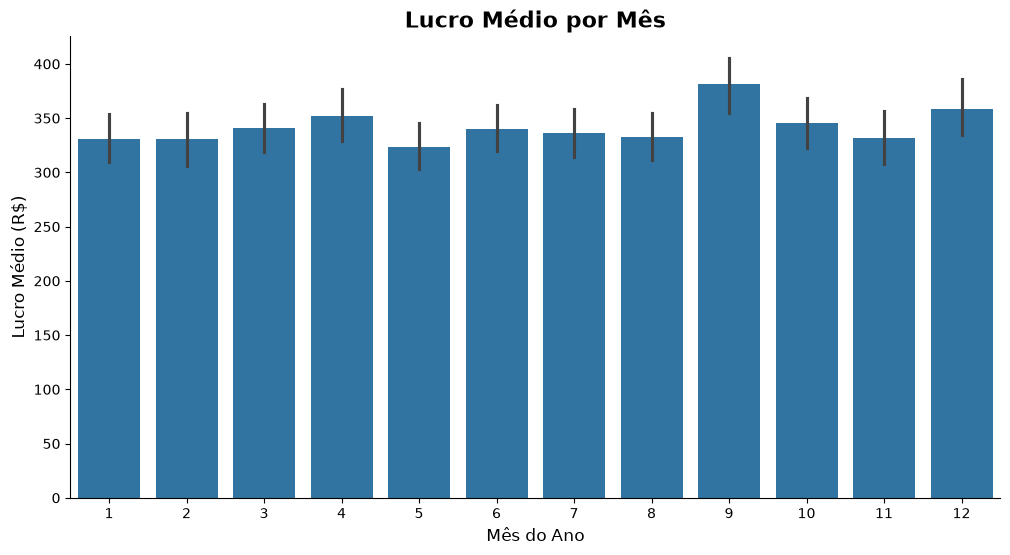

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#ajustando o tamanho da figura 
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df, 
    x='mes', 
    y='lucro_estimado', 
)

plt.title('Lucro Médio por Mês', fontsize=16, fontweight='bold')
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Lucro Médio (R$)', fontsize=12)

plt.xticks(rotation=0) 

sns.despine()


plt.show()

É possível perceber que setembro é o mês com maior lucro. Nota-se também que não há uma variância alta entre os meses.
## Gráfico de Linhas

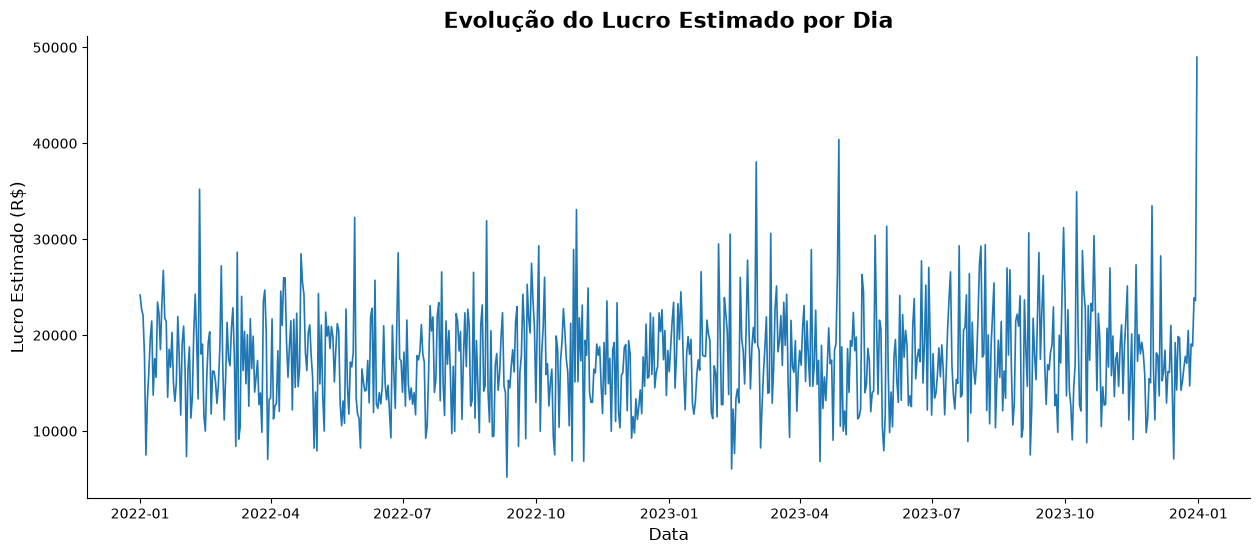

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

#agrupando os dados por dia
lucro_diario = df.groupby('data_venda')['lucro_estimado'].sum().reset_index()

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=lucro_diario, 
    x='data_venda', 
    y='lucro_estimado', 
    linewidth=1.2, 
)

plt.title('Evolução do Lucro Estimado por Dia', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Lucro Estimado (R$)', fontsize=12)

plt.xticks(rotation=0)

sns.despine()

plt.show()

O gráfico mostra uma alta volatilidade no lucro diário da empresa.

## Gráfico de dispersão

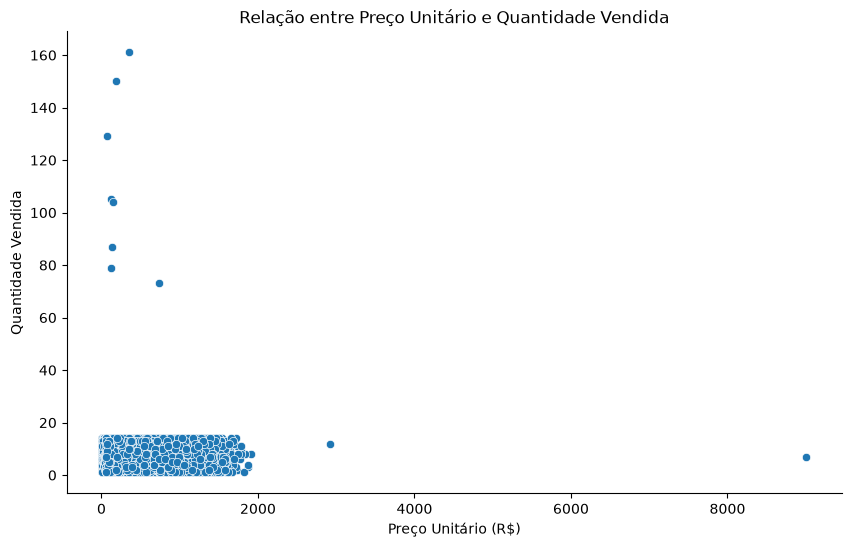

In [207]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='preco_unitario', y='quantidade')

plt.title('Relação entre Preço Unitário e Quantidade Vendida')
plt.xlabel('Preço Unitário (R$)')
plt.ylabel('Quantidade Vendida')
sns.despine()
plt.show()

Podemos perceber que a maior parte das vendas possui entre 0 e 20 unidades e preço unitário entre 0 e 2000 reais.

## Mapa de calor

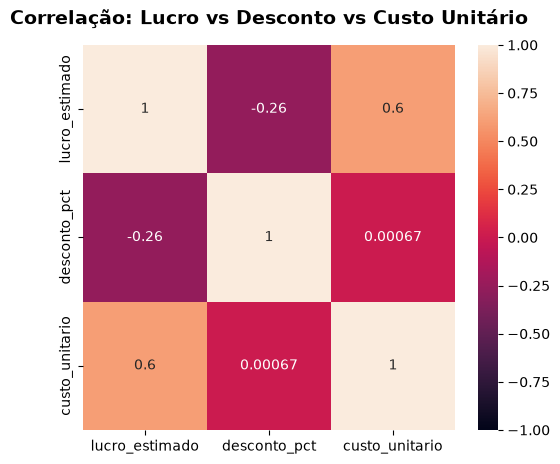

In [208]:
colunas_interesse = ['lucro_estimado', 'desconto_pct', 'custo_unitario']

corr_subset = df[colunas_interesse].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_subset, 
    annot=True,            #essa opcao mostra os valores
    vmin=-1, vmax=1,       #escala da correlaçao
)

plt.title('Correlação: Lucro vs Desconto vs Custo Unitário', fontsize=14, fontweight='bold', pad=15)
plt.show()

Com o gráfico acima, podemos perceber que:
1. A porcentagem de desconto e o lucro estimado possui uma correlação negativa fraca. Assim, a medida que o desconto aumenta, o lucro esperado diminui levemente.
2. O lucro estimado e o custo unitário dos produtos possui uma correlação positiva moderada. Assim, produtos com custo unitário elevados tendem a gerar lucros estimados maiores
3. Porcentagem de desconto e custo unitário. A correlação é praticamente nula. O desconto não está vinculado ao preço unitário